In [ ]:
import numpy as np 
from pathlib import Path
import SimpleITK as sitk

data_dir = Path("/gpfs/work1/0/prjs0971/glioseg/data/BraTS2023_relabeled_2/Patients")

for patient in data_dir.iterdir(): 
    if patient.is_dir(): 
        print(f"Processing patient: {patient.name}")
        resampled_segmentations_dir = patient / "SEGMENTATIONS" / "RESAMPLED"
        for modality in ["T1", "T1GD", "T2", "FLAIR"]: 
            brain_mask_dir = resampled_segmentations_dir / f"mask_brain_{modality}.nii.gz"
            if brain_mask_dir.exists():
                brain_mask_itk = sitk.ReadImage(str(brain_mask_dir))
                brain_mask = sitk.GetArrayFromImage(brain_mask_itk)

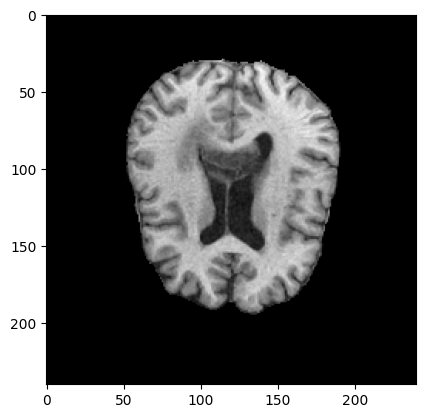

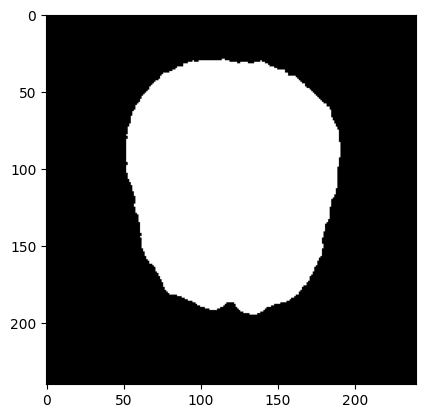

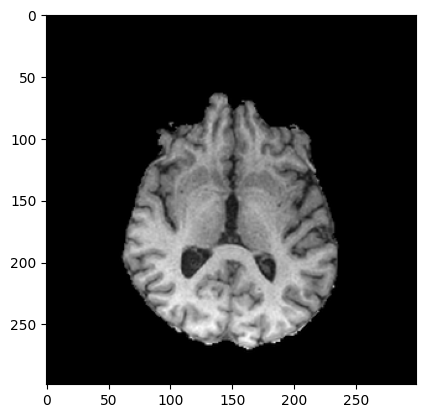

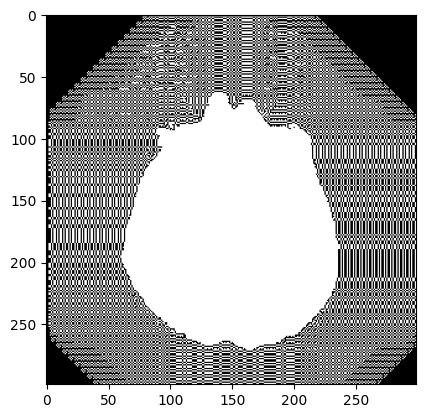

In [11]:
import SimpleITK as sitk
import matplotlib.pyplot as plt

im_reoriented_dir = "/projects/0/prjs0971/glioseg/data/BraTS2023_relabeled_2/Patients_failed/BraTS-GLI-01332-000/REORIENTED/T1.nii.gz"
im_resampled_dir = "/projects/0/prjs0971/glioseg/data/BraTS2023_relabeled_2/Patients_failed/BraTS-GLI-01332-000/RESAMPLED/T1.nii.gz"
im_resampled = sitk.ReadImage(im_resampled_dir)
im_reoriented = sitk.ReadImage(im_reoriented_dir)
# brain_mask_resampled = sitk.OtsuThreshold(im_resampled, 0, 1)
# brain_mask_reoriented = sitk.OtsuThreshold(im_reoriented, 0, 1)

brain_mask_resampled = sitk.Cast(im_resampled > 0, sitk.sitkUInt8)
brain_mask_reoriented = sitk.Cast(im_reoriented > 0, sitk.sitkUInt8)

plt.imshow(sitk.GetArrayFromImage(im_reoriented)[80, :, :], cmap="gray")
plt.figure()
plt.imshow(sitk.GetArrayFromImage(brain_mask_reoriented)[80, :, :], cmap="gray")
plt.figure()
plt.imshow(sitk.GetArrayFromImage(im_resampled)[80, :, :], cmap="gray")
plt.figure()
plt.imshow(sitk.GetArrayFromImage(brain_mask_resampled)[80, :, :], cmap="gray")
plt.show()